# manuscript_lr — сравнение 4 моделей

| Вариант | Подсети | Нормализация |
|---------|---------|---------------|
| `subnets_none` | да | нет |
| `subnets_zscore` | да | Z-score |
| `shared_none` | нет | нет |
| `shared_zscore` | нет | Z-score |

Precompute (по желанию): `python experiments/manuscript_lr/e1_precompute_all.py`

In [5]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use("default")
mpl.rcdefaults()

def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "neuromaps").is_dir() and (p / "experiments" / "manuscript_lr" / "e1_config.py").is_file():
            return p
    raise FileNotFoundError(
        "Не найден корень репозитория (neuromaps/ + experiments/manuscript_lr/). "
        "Запустите ноутбук из neuromap_sync или experiments/manuscript_lr."
    )

ROOT = _find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.manuscript_lr.e1_config import (
    EXP_DIR,
    TRAINING_VARIANTS,
    CHECKPOINTS_ROOT,
    checkpoint_dir,
    model_ckpt_path,
    results_dir,
)
from neuromaps.nm_manuscript_lr import NeuroMapManuscriptLR

EXP = EXP_DIR
VARIANT_NAMES = [v["name"] for v in TRAINING_VARIANTS]
COLORS = {"subnets_none": "C0", "subnets_zscore": "C1", "shared_none": "C2", "shared_zscore": "C3"}

print("ROOT:", ROOT)
print("EXP:", EXP)
print("CHECKPOINTS_ROOT:", CHECKPOINTS_ROOT)
for v in VARIANT_NAMES:
    p = model_ckpt_path(v)
    print(f"  {v}: exists={p.is_file()}  {p}")

ROOT: /Users/apanyushev/neuromap_sync
EXP: /Users/apanyushev/neuromap_sync/experiments/manuscript_lr
CHECKPOINTS_ROOT: /Users/apanyushev/neuromap_sync/experiments/manuscript_lr/checkpoints
  subnets_none: exists=True  /Users/apanyushev/neuromap_sync/experiments/manuscript_lr/checkpoints/subnets_none/model.ckpt
  subnets_zscore: exists=True  /Users/apanyushev/neuromap_sync/experiments/manuscript_lr/checkpoints/subnets_zscore/model.ckpt
  shared_none: exists=True  /Users/apanyushev/neuromap_sync/experiments/manuscript_lr/checkpoints/shared_none/model.ckpt
  shared_zscore: exists=True  /Users/apanyushev/neuromap_sync/experiments/manuscript_lr/checkpoints/shared_zscore/model.ckpt


## Загрузка моделей и сводка обучения

In [6]:
models = {}
histories = {}
summary_rows = []

for v in TRAINING_VARIANTS:
    name = v["name"]
    ckpt = model_ckpt_path(name)
    hist_path = checkpoint_dir(name) / "history.json"

    if not ckpt.is_file():
        print(f"⚠ пропуск {name}: нет {ckpt}")
        continue

    models[name] = NeuroMapManuscriptLR.load(str(ckpt), device="cpu")
    m = models[name]
    print(
        f"{name}: use_subnets={m.use_subnets}, norm_mode={m.norm_mode!r}, "
        f"best checkpoint loaded"
    )

    if hist_path.is_file():
        with open(hist_path, encoding="utf-8") as f:
            histories[name] = json.load(f)
        h = histories[name]
        summary_rows.append({
            "variant": name,
            "subnets": v["use_subnets"],
            "zscore": v["norm_mode"] == "zscore",
            "best_val_mae": h.get("best_val_loss"),
            "best_epoch": h.get("best_epoch"),
            "final_val_mae": h["val_loss"][-1] if h.get("val_loss") else None,
        })

print(f"\nЗагружено моделей: {len(models)} / {len(TRAINING_VARIANTS)}")

subnets_none: use_subnets=True, norm_mode='none', best checkpoint loaded
subnets_zscore: use_subnets=True, norm_mode='zscore', best checkpoint loaded
shared_none: use_subnets=False, norm_mode='none', best checkpoint loaded
shared_zscore: use_subnets=False, norm_mode='zscore', best checkpoint loaded

Загружено моделей: 4 / 4


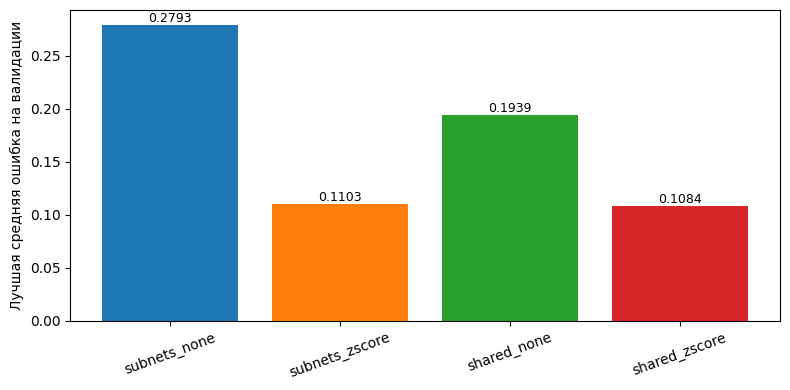

subnets_none      best=0.279312 @ epoch 995  final_val=0.279603
subnets_zscore    best=0.110284 @ epoch 997  final_val=0.110580
shared_none       best=0.193912 @ epoch 996  final_val=0.194359
shared_zscore     best=0.108442 @ epoch 993  final_val=0.108611


In [47]:
if summary_rows:
    labels = [r["variant"] for r in summary_rows]
    bests = [r["best_val_mae"] for r in summary_rows]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(labels, bests, color=[COLORS.get(l, "gray") for l in labels])
    ax.set_ylabel("Лучшая средняя ошибка на валидации")
    ax.tick_params(axis="x", rotation=20)
    for b, val in zip(bars, bests):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{val:.4f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

    for r in summary_rows:
        print(
            f"{r['variant']:16s}  best={r['best_val_mae']:.6f} @ epoch {r['best_epoch']}  "
            f"final_val={r['final_val_mae']:.6f}"
        )

## Кривые обучения

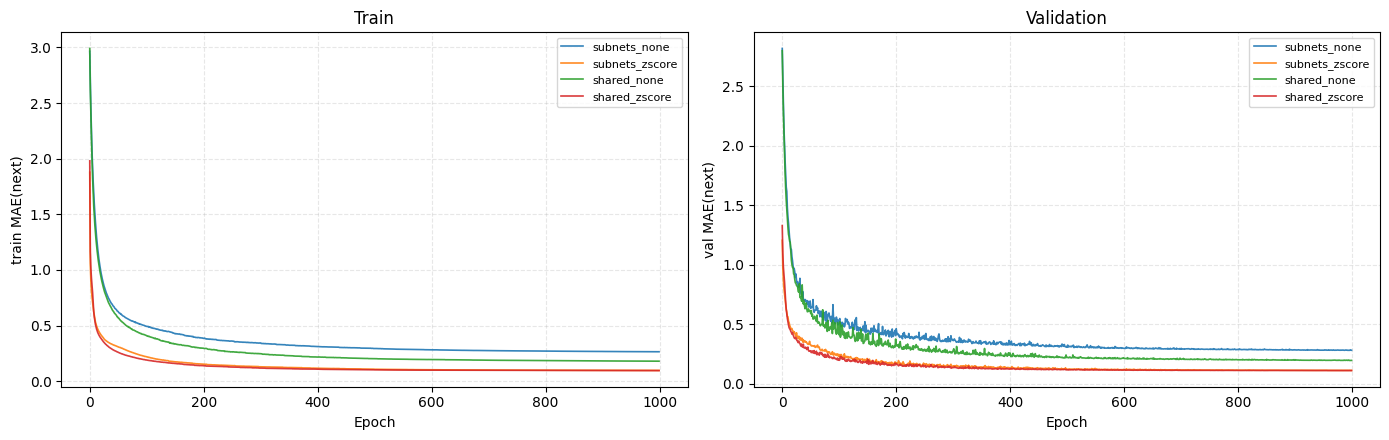

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for name, h in histories.items():
    c = COLORS.get(name, None)
    axes[0].plot(h["train_loss"], label=name, lw=1.2, alpha=0.9, color=c)
    axes[1].plot(h["val_loss"], label=name, lw=1.2, alpha=0.9, color=c)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("train MAE(next)")
axes[0].set_title("Train")
axes[0].legend(fontsize=8)
axes[0].grid(True, ls="--", alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("val MAE(next)")
axes[1].set_title("Validation")
axes[1].legend(fontsize=8)
axes[1].grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

## P(НТ) по (λ, β)

ODE — из `results/` этого эксперимента или `manuscript_1/results/`. Neuromap — `results/<variant>/` после precompute.

In [19]:
from utils import plot_heatmap

ode_candidates = [
    EXP / "results" / "e1_ode_fixed_point_probability.npz",
    ROOT / "experiments/manuscript_1/results/e1_ode_fixed_point_probability.npz",
]
ode_path = next((p for p in ode_candidates if p.is_file()), None)

p_nm_by_variant = {}
for name in models:
    for base in (results_dir(name), EXP / "results"):
        p = base / "e1_neuromap_fixed_point_probability.npz"
        if p.is_file():
            p_nm_by_variant[name] = np.load(p)["P"]
            break

if ode_path is None:
    print("ODE P(НТ): нет npz — запустите e1_precompute_fixed_point_probability.py")
else:
    ode_data = np.load(ode_path)
    alpha_grid, beta_grid = ode_data["alpha_grid"], ode_data["beta_grid"]
    p_ode = ode_data["P"]
    print("ODE from:", ode_path)

if not p_nm_by_variant:
    print("Neuromap P(НТ): нет npz — запустите e1_precompute_all.py")
else:
    print("Neuromap variants with data:", list(p_nm_by_variant.keys()))

if ode_path is None and not p_nm_by_variant:
    alpha_grid = beta_grid = None

ODE from: /Users/apanyushev/neuromap_sync/experiments/manuscript_1/results/e1_ode_fixed_point_probability.npz
Neuromap variants with data: ['subnets_none', 'subnets_zscore', 'shared_none', 'shared_zscore']


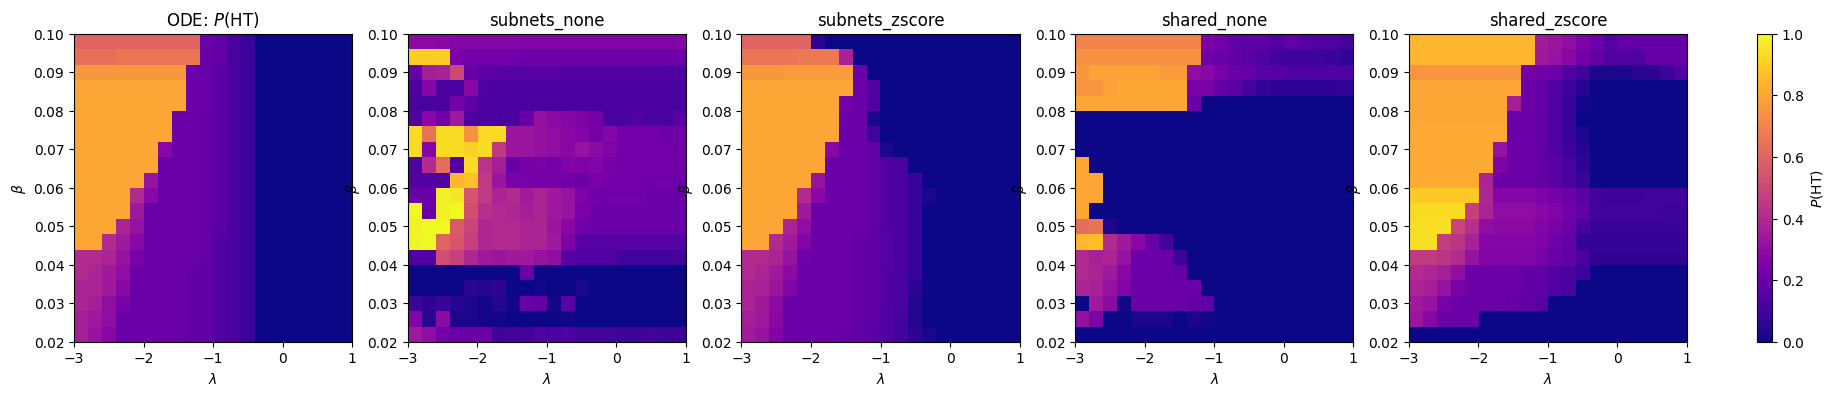

In [46]:
# Построй все вместе одним рядом 5x1: сначала ODE, потом 4 варианта neuromap (если есть)
num_nm = len(p_nm_by_variant)
plot_total = 1 + num_nm if ode_path is not None else num_nm

if plot_total == 0:
    if not p_nm_by_variant:
        print("Neuromap P(НТ): нет npz — запустите e1_precompute_all.py")
    if ode_path is None:
        print("ODE P(НТ): нет npz — запустите e1_precompute_fixed_point_probability.py")
elif plot_total > 0:
    # Собрать все матрицы P для нормализации colormap
    ps = []
    if ode_path is not None:
        ps.append(p_ode)
    for name in p_nm_by_variant:
        ps.append(p_nm_by_variant[name])
    import numpy as np
    vmin = min(p.min() for p in ps)
    vmax = max(p.max() for p in ps)

    import matplotlib as mpl

    fig, axes = plt.subplots(1, plot_total, figsize=(4.5 * plot_total, 4), squeeze=False)
    axes = axes[0]  # 1D array of axes

    im_handles = []

    ax_idx = 0
    # ODE (если есть)
    if ode_path is not None:
        img = axes[ax_idx].imshow(
            p_ode, origin='lower', aspect='auto',
            extent=[alpha_grid[0], alpha_grid[-1], beta_grid[0], beta_grid[-1]],
            vmin=vmin, vmax=vmax, cmap='plasma'
        )
        axes[ax_idx].set_xlabel(r"$\lambda$")
        axes[ax_idx].set_ylabel(r"$\beta$")
        axes[ax_idx].set_title("ODE: $P(\\mathrm{НТ})$")
        im_handles.append(img)
        ax_idx += 1
    # neuromap варианты
    for name, p_nm in p_nm_by_variant.items():
        img = axes[ax_idx].imshow(
            p_nm, origin='lower', aspect='auto',
            extent=[alpha_grid[0], alpha_grid[-1], beta_grid[0], beta_grid[-1]],
            vmin=vmin, vmax=vmax, cmap='plasma'
        )
        axes[ax_idx].set_xlabel(r"$\lambda$")
        axes[ax_idx].set_ylabel(r"$\beta$")
        axes[ax_idx].set_title(name)
        im_handles.append(img)
        ax_idx += 1

    # Один colorbar для всех — размещаем справа через fig.colorbar, но не добавляем отдельный Axes вручную,
    # чтобы не вызвать warning о tight_layout (plt.tight_layout() + лишний axes -> warning).
    # Передаем ax=axes, чтобы colorbar был совместим с макетом (боковой короткий, fraction и pad регулируют положение).
    cbar = fig.colorbar(im_handles[0], ax=axes, orientation="vertical", fraction=0.035, pad=0.04)
    cbar.set_label("$P(\\mathrm{НТ})$")
    # Do not call plt.tight_layout() after colorbar, 
    # as Matplotlib warns in such arrangements — instead, layout should be fine as is.
    plt.show()

## Траектории ODE vs neuromap (одни и те же IC)

In [ ]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems.vdp_mod1 import vdp_mod1_rk4, vdp_mod1_right_part

cases = [
    {"u0": [-10.0, 0.0], "p": [-1.0, 0.07], "n_steps": 20_000},
    {"u0": [-10.0, 0.0], "p": [-2.5, 0.08], "n_steps": 20_000},
]

for case in cases:
    u0, p = case["u0"], case["p"]
    ode_traj = get_attractor_trajectory(
        vdp_mod1_rk4, vdp_mod1_right_part, u0, p, 0.01, 300, 200,
        lambda x, y: x[1], lambda x, y: [0, 1], divergence_threshold=1e3,
    )

    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4), squeeze=False)
    if n_models == 0:
        raise RuntimeError("Нет загруженных моделей")

    for ax, (name, model) in zip(axes[0], models.items()):
        nm_traj = model.simulate(u0=u0, p=p, n_steps=case["n_steps"], verbose=False, divergence_threshold=1e3)
        ax.set_title(name, fontsize=10)
        if nm_traj is None:
            ax.text(0.5, 0.5, "diverged", ha="center", va="center", transform=ax.transAxes)
            continue
        ax.plot(ode_traj[:, 0], ode_traj[:, 1], lw=0.8, alpha=0.5, color="gray", label="ODE")
        ax.plot(nm_traj[:, 0], nm_traj[:, 1], lw=0.8, alpha=0.9, color=COLORS.get(name, "C0"), label="NM")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    fig.suptitle(rf"$u_0={u0}$, $\lambda={p[0]}$, $\beta={p[1]}$", y=1.02)
    plt.tight_layout()
    plt.show()

## Басейны амплитуд (2×2, если есть precompute)

In [ ]:
from utils import plot_compare_amplitude_basins

basin_by_variant = {}
for name in models:
    for base in (results_dir(name), EXP / "results"):
        p = base / "e1_amplitude_basin.npz"
        if p.is_file():
            basin_by_variant[name] = np.load(p)
            break

if not basin_by_variant:
    print("Нет e1_amplitude_basin.npz — e1_precompute_amplitude_basins.py --variant <name>")
else:
    names = list(basin_by_variant.keys())
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()
    ref = basin_by_variant[names[0]]
    x_grid, y_grid = ref["x_grid"], ref["y_grid"]

    for ax, name in zip(axes, VARIANT_NAMES):
        if name not in basin_by_variant:
            ax.set_visible(False)
            continue
        b = basin_by_variant[name]
        z_ode, z_nm = b["Z_ode"], b["Z_nm"]
        # сравнение ODE|NM в одной панели: показываем NM (главное для neuromap)
        im = ax.imshow(
            z_nm,
            extent=[x_grid[0], x_grid[-1], y_grid[0], y_grid[-1]],
            origin="lower",
            aspect="auto",
            cmap="plasma",
        )
        ax.set_title(f"{name} (NM integrated)")
        ax.set_xlabel(r"$u_1$")
        ax.set_ylabel(r"$u_2$")
        fig.colorbar(im, ax=ax, fraction=0.046)

    for j in range(len(names), 4):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

    # полное сравнение ODE vs NM для одного выбранного варианта
    show_name = names[0]
    b = basin_by_variant[show_name]
    plot_compare_amplitude_basins(
        b["x_grid"], b["y_grid"], b["Z_ode"], b["Z_nm"],
        x_label=r"$u_1$", y_label=r"$u_2$", cmap="plasma", bad_color="black",
    )
    plt.suptitle(f"ODE vs NM — {show_name}", y=1.02)
    plt.show()

## Скан ‖u*‖ и ln max|μ| (2×2)

In [ ]:
scan_by_variant = {}
for name in models:
    for base in (results_dir(name), EXP / "results"):
        found = sorted(base.glob("e1_neuromap_scan_residual_*.npz"))
        if found:
            scan_by_variant[name] = np.load(found[0])
            break

if not scan_by_variant:
    print("Нет scan npz — e1_precompute_neuromap_scan_residual.py")
else:
    fig, axes = plt.subplots(len(scan_by_variant), 2, figsize=(10, 3.5 * len(scan_by_variant)), squeeze=False)
    for row, (name, data) in enumerate(scan_by_variant.items()):
        dist_z, log_z = data["dist_Z"], data["log_rho_Z"]
        xg, yg = data["xg"], data["yg"]
        for col, (z, ttl) in enumerate([(dist_z, r"$\|u^*\|$"), (log_z, r"$\ln\max|\mu|$")]):
            ax = axes[row, col]
            im = ax.imshow(z, extent=[xg[0], xg[-1], yg[0], yg[-1]], origin="lower", aspect="auto", cmap="plasma")
            ax.set_xlabel(r"$\lambda$")
            ax.set_ylabel(r"$\beta$")
            ax.set_title(f"{name}: {ttl}")
            fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()

## Фазовые портреты и НТ (2×2, λ=-1, β=0.05)

In [ ]:
from utils.nn_map_fixed_points import collect_fixed_points_grid_starts

lam, beta = -1.0, 0.05
p_fixed = [float(lam), float(beta)]
p_2d = np.array([[lam, beta]], dtype=np.float64)
initial_conditions = [(5.0, 20.0), (0.0, 0.5)]
n_steps, n_transient = 8000, 1000

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.ravel()

for ax, name in zip(axes, VARIANT_NAMES):
    if name not in models:
        ax.set_visible(False)
        continue
    model = models[name]
    fixed_pts = collect_fixed_points_grid_starts(
        model, p_fixed,
        (np.linspace(-15, 15, 12), np.linspace(-35, 35, 12)),
        residual_tol=1e-7, unique_tol=1e-3,
    )
    for u1, u2 in initial_conditions:
        u0 = np.array([[u1, u2]], dtype=np.float64)
        traj = model.simulate(u0, p_2d, n_steps, verbose=False, divergence_threshold=1e3)
        if traj is not None and len(traj) > n_transient + 1:
            traj = traj[n_transient:]
            ax.plot(traj[:, 0], traj[:, 1], lw=0.8, alpha=0.85)
    if fixed_pts:
        fp = np.stack([np.asarray(u, dtype=float).ravel() for u in fixed_pts])
        ax.scatter(fp[:, 0], fp[:, 1], s=80, marker="*", c="gold", edgecolors="k", linewidths=0.5, zorder=5)
    ax.set_title(f"{name} ({len(fixed_pts)} НТ)")
    ax.set_xlabel(r"$u_1$")
    ax.set_ylabel(r"$u_2$")
    ax.grid(True, alpha=0.3)

fig.suptitle(rf"$\lambda={lam}$, $\beta={beta}$", y=1.01)
plt.tight_layout()
plt.show()